# Exploratory Data Analysis

In [1]:
import os, re, ast, glob, math, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
random.seed(42); np.random.seed(42)

CANDIDATE_ROOTS = [
    "/kaggle/input/competitions/birdclef-2026",
    "/kaggle/input/birdclef-2026",
    "/content/birdclef-2026",
    "./birdclef-2026",
]
DATA_ROOT = next((p for p in CANDIDATE_ROOTS if os.path.isdir(p)), CANDIDATE_ROOTS[0])

FIG_DIR = Path("/kaggle/working/reports/figures") if os.path.isdir("/kaggle/working") else Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / name, dpi=120, bbox_inches="tight")
    plt.show()

print("DATA_ROOT :", DATA_ROOT, "| exists:", os.path.isdir(DATA_ROOT))
print("FIG_DIR   :", FIG_DIR)

DATA_ROOT : /kaggle/input/competitions/birdclef-2026 | exists: True
FIG_DIR   : /kaggle/working/reports/figures


In [6]:
def read_csv_safe(name):
    p = os.path.join(DATA_ROOT, name)
    return pd.read_csv(p) if os.path.exists(p) else None

train      = read_csv_safe("train.csv")
taxonomy   = read_csv_safe("taxonomy.csv")
ss_labels  = read_csv_safe("train_soundscapes_labels.csv")
sample_sub = read_csv_safe("sample_submission.csv")

for nm, df in [("train", train), ("taxonomy", taxonomy),
               ("train_soundscapes_labels", ss_labels), ("sample_submission", sample_sub)]:
    print(f"{nm:28s} -> {None if df is None else df.shape}")
    if df is not None:
        print("    cols:", list(df.columns))

train                        -> (35549, 15)
    cols: ['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']
taxonomy                     -> (234, 5)
    cols: ['primary_label', 'inat_taxon_id', 'scientific_name', 'common_name', 'class_name']
train_soundscapes_labels     -> (1478, 4)
    cols: ['filename', 'start', 'end', 'primary_label']
sample_submission            -> (3, 235)
    cols: ['row_id', '1161364', '116570', '1176823', '1491113', '1595929', '209233', '22930', '22956', '22961', '22967', '22973', '22983', '22985', '23150', '23154', '23158', '23176', '23724', '24279', '24285', '24287', '24321', '244024', '25073', '25092', '25214', '326272', '41970', '43435', '47144', '47158son01', '47158son02', '47158son03', '47158son04', '47158son05', '47158son06', '47158son07', '47158son08', '47158son09', '47158son10', '47158son11', '47158son12', '4

In [7]:
if sample_sub is not None:
    species = [c for c in sample_sub.columns if c != "row_id"]
    print("submission rows:", len(sample_sub), "| target classes:", len(species))
    print("example row_id:", sample_sub["row_id"].iloc[0] if len(sample_sub) else "n/a")
train.head()

submission rows: 3 | target classes: 234
example row_id: BC2026_Test_0001_S05_20250227_010002_5


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


## Класи та таксономічні групи

Num target classes: 234
taxonomy group column: class_name
class_name
Aves        162
Amphibia     35
Insecta      28
Mammalia      8
Reptilia      1
Name: count, dtype: int64


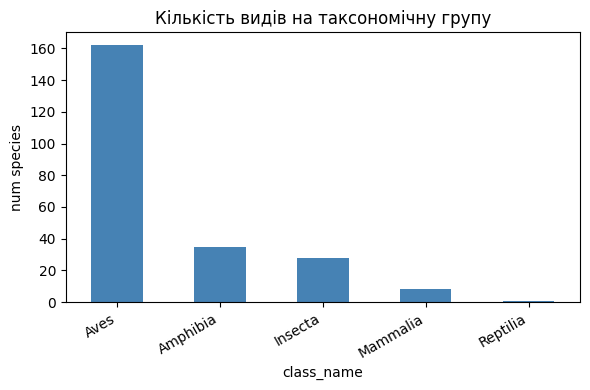

In [8]:
if sample_sub is not None:
    species = [c for c in sample_sub.columns if c != "row_id"]
elif taxonomy is not None:
    species = sorted(taxonomy["primary_label"].astype(str).unique())
else:
    species = sorted(train["primary_label"].astype(str).unique())
print("Num target classes:", len(species))

group_col = None
if taxonomy is not None:
    for c in ["class_name", "class", "taxon", "group", "category", "taxonomic_group"]:
        if c in taxonomy.columns:
            group_col = c; break
print("taxonomy group column:", group_col)

if group_col is not None:
    g = taxonomy[group_col].value_counts()
    print(g)
    plt.figure(figsize=(6, 4))
    g.plot.bar(color="steelblue")
    plt.title("Кількість видів на таксономічну групу")
    plt.ylabel("num species"); plt.xticks(rotation=30, ha="right")
    savefig("01_taxa_groups.png")

recordings per species -> min 1 | median 125 | mean 172.6 | max 499
species with <10 recordings: 25 / 206 (12%)


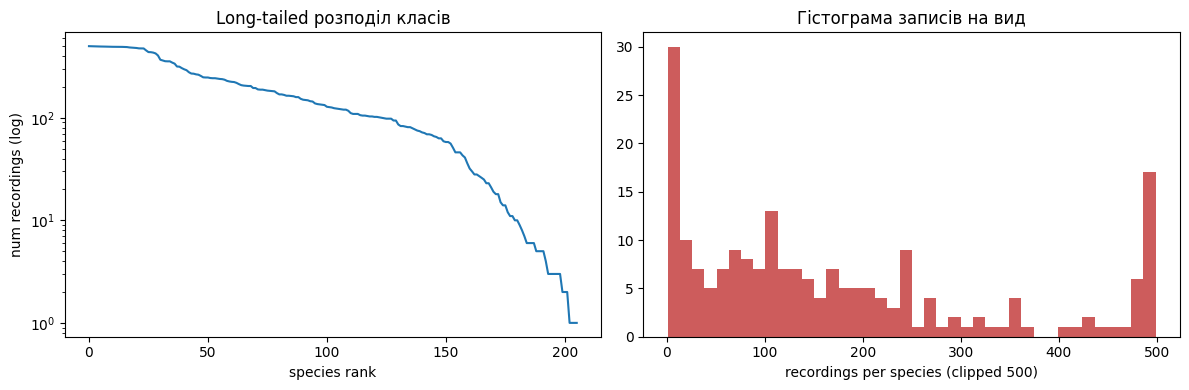


Найрідкісніші 15 видів:
primary_label
23154      5
23176      4
476521     3
25214      3
64898      3
74580      3
555123     3
sptnig1    3
24321      2
70711      2
209233     2
516975     1
23724      1
116570     1
23150      1
Name: count, dtype: int64


In [9]:
vc = train["primary_label"].value_counts()
print("recordings per species -> min %d | median %.0f | mean %.1f | max %d"
      % (vc.min(), vc.median(), vc.mean(), vc.max()))
print("species with <10 recordings: %d / %d (%.0f%%)"
      % (int((vc < 10).sum()), len(vc), 100 * (vc < 10).mean()))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(np.arange(len(vc)), vc.values)
ax[0].set_yscale("log"); ax[0].set_xlabel("species rank")
ax[0].set_ylabel("num recordings (log)"); ax[0].set_title("Long-tailed розподіл класів")
ax[1].hist(np.clip(vc.values, 0, 500), bins=40, color="indianred")
ax[1].set_xlabel("recordings per species (clipped 500)"); ax[1].set_title("Гістограма записів на вид")
savefig("02_class_longtail.png")

print("\nНайрідкісніші 15 видів:")
print(vc.tail(15))

## Метадані 

rating==0 (unrated): 12849 | rating>=3: 21295


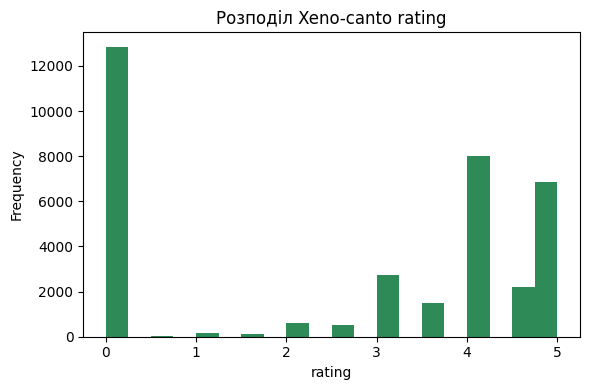

In [10]:
if "rating" in train.columns:
    print("rating==0 (unrated):", int((train["rating"] == 0).sum()),
          "| rating>=3:", int((train["rating"] >= 3).sum()))
    plt.figure(figsize=(6, 4))
    train["rating"].plot.hist(bins=20, color="seagreen")
    plt.title("Розподіл Xeno-canto rating"); plt.xlabel("rating")
    savefig("03_rating.png")
else:
    print("no 'rating' column")

clips with >=1 secondary label: 12.3%
avg secondary labels per clip: 0.209


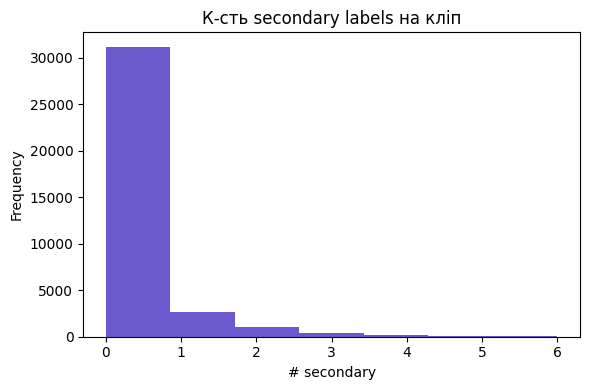

In [11]:
def parse_sec(x):
    if not isinstance(x, str) or x in ("", "[]"): return []
    try: return ast.literal_eval(x)
    except: return [t.strip() for t in x.split(";") if t.strip()]

if "secondary_labels" in train.columns:
    nsec = train["secondary_labels"].apply(lambda x: len(parse_sec(x)))
    print("clips with >=1 secondary label: %.1f%%" % (100 * (nsec > 0).mean()))
    print("avg secondary labels per clip:", round(nsec.mean(), 3))
    plt.figure(figsize=(6, 4))
    nsec.clip(0, 6).plot.hist(bins=7, color="slateblue")
    plt.title("К-сть secondary labels на кліп"); plt.xlabel("# secondary")
    savefig("04_secondary.png")
else:
    print("no 'secondary_labels' column")

sampled files: 1500
duration s -> p50=21.4  p90=73.9  p99=238.4  max=663.4
sample rates: {32000: 1500}
channels    : {1: 1500}


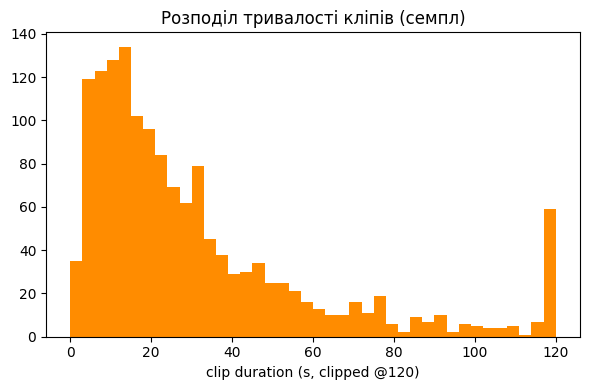

In [12]:
import soundfile as sf
audio_dir = os.path.join(DATA_ROOT, "train_audio")
paths = train["filename"].tolist() if "filename" in train.columns else []
sample = random.Random(42).sample(paths, min(1500, len(paths)))

durs, srs, chs = [], [], []
for fn in sample:
    try:
        info = sf.info(os.path.join(audio_dir, fn))
        durs.append(info.frames / info.samplerate); srs.append(info.samplerate); chs.append(info.channels)
    except Exception:
        pass

durs = np.array(durs)
print("sampled files:", len(durs))
if len(durs):
    print("duration s -> p50=%.1f  p90=%.1f  p99=%.1f  max=%.1f"
          % (np.median(durs), np.percentile(durs, 90), np.percentile(durs, 99), durs.max()))
    print("sample rates:", pd.Series(srs).value_counts().to_dict())
    print("channels    :", pd.Series(chs).value_counts().to_dict())
    plt.figure(figsize=(6, 4))
    plt.hist(np.clip(durs, 0, 120), bins=40, color="darkorange")
    plt.xlabel("clip duration (s, clipped @120)"); plt.title("Розподіл тривалості кліпів (семпл)")
    savefig("05_duration.png")

## focal vs soundscape, labeled vs unlabeled

focal (train_audio) clips : 35549
soundscape files (total)  : 10658
soundscape files (labeled): 66


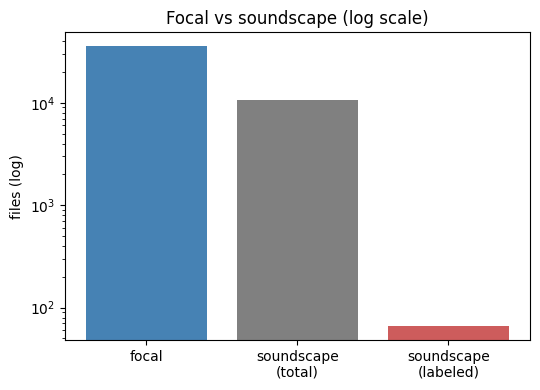

In [13]:
n_focal = len(train)
sc_dir = os.path.join(DATA_ROOT, "train_soundscapes")
n_sc = sum(len(glob.glob(os.path.join(sc_dir, f"*.{e}"))) for e in ["ogg", "wav", "flac"])
n_sc_lab = 0 if ss_labels is None else ss_labels["filename"].nunique()

print(f"focal (train_audio) clips : {n_focal}")
print(f"soundscape files (total)  : {n_sc}")
print(f"soundscape files (labeled): {n_sc_lab}")

plt.figure(figsize=(5.5, 4))
bars = plt.bar(["focal", "soundscape\n(total)", "soundscape\n(labeled)"],
               [n_focal, max(n_sc, 1), max(n_sc_lab, 1)],
               color=["steelblue", "gray", "indianred"])
plt.yscale("log"); plt.title("Focal vs soundscape (log scale)"); plt.ylabel("files (log)")
savefig("06_domain_gap.png")

## Site / hour патерни

sites: ['S03', 'S08', 'S09', 'S13', 'S15', 'S18', 'S19', 'S22', 'S23']
hours present: [0, 1, 2, 3, 4, 6, 7, 18, 19, 20, 21, 22, 23]


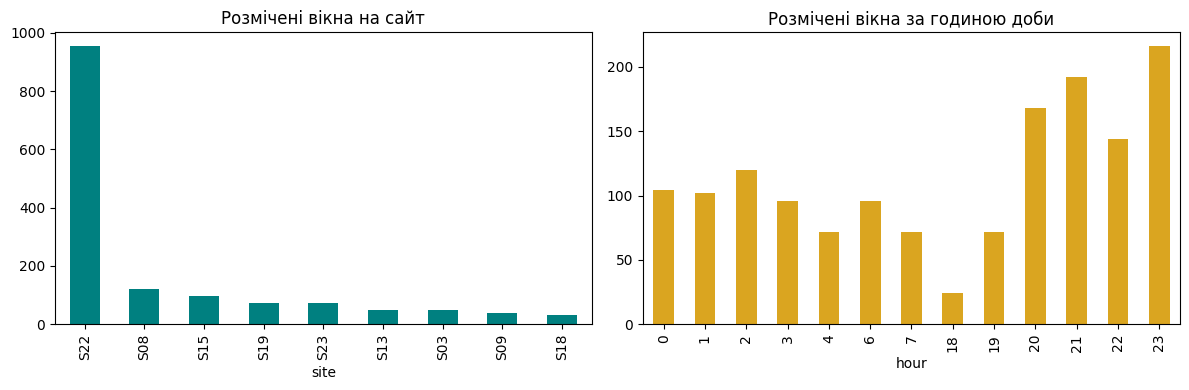

In [14]:
FNAME_RE = re.compile(r"BC2026_(?:Train|Test)_(\d+)_(S\d+)_(\d{8})_(\d{6})")
def parse_fname(name):
    m = FNAME_RE.match(str(name))
    if not m: return None, -1
    _, site, _, hms = m.groups()
    return site, int(hms[:2])

if ss_labels is not None:
    sh = ss_labels.copy()
    sh[["site", "hour"]] = sh["filename"].apply(lambda n: pd.Series(parse_fname(n)))
    print("sites:", sorted([s for s in sh["site"].dropna().unique()]))
    print("hours present:", sorted([int(h) for h in sh["hour"].unique() if h >= 0]))
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sh["site"].value_counts().plot.bar(ax=ax[0], color="teal", title="Розмічені вікна на сайт")
    sh[sh.hour >= 0]["hour"].value_counts().sort_index().plot.bar(
        ax=ax[1], color="goldenrod", title="Розмічені вікна за годиною доби")
    ax[1].set_xlabel("hour")
    savefig("07_site_hour.png")
else:
    print("no train_soundscapes_labels.csv -> skip site/hour")

## mel-спектрограм

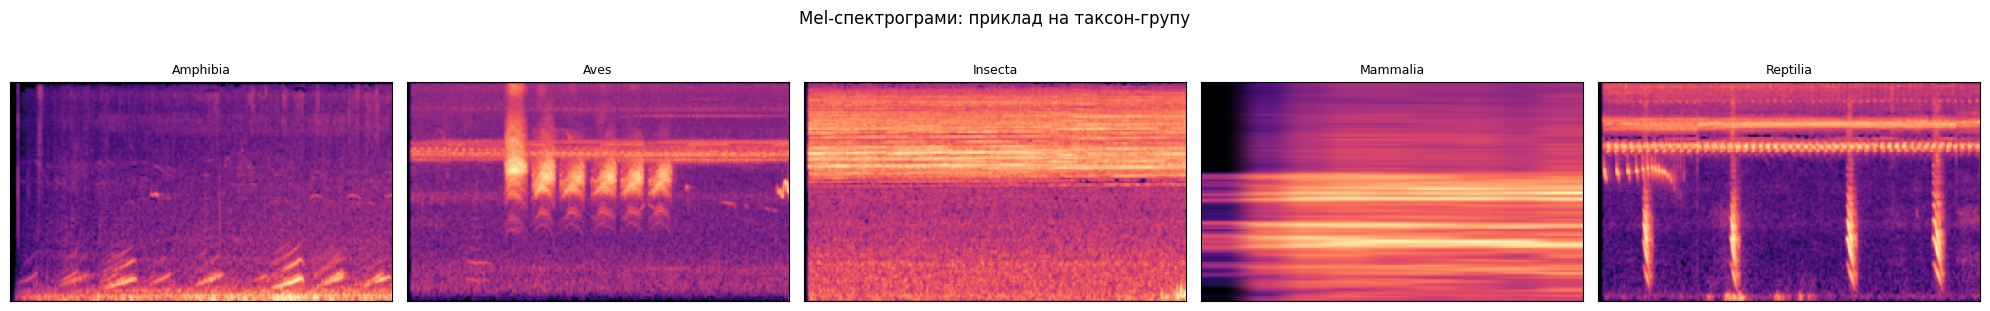

In [ ]:
import torch, torchaudio
SR, NFFT, HOP, NMELS = 32000, 2048, 512, 128
mel_t = torchaudio.transforms.MelSpectrogram(SR, NFFT, hop_length=HOP, n_mels=NMELS,
                                             f_min=20, f_max=16000, power=2.0)
to_db = torchaudio.transforms.AmplitudeToDB(top_db=80)

def load_mel(fp, seconds=5):
    w, sr = torchaudio.load(fp)
    if w.shape[0] > 1: w = w.mean(0, keepdim=True)
    if sr != SR: w = torchaudio.functional.resample(w, sr, SR)
    w = w[:, :SR * seconds]
    return to_db(mel_t(w)).squeeze(0).numpy()

examples = {}
if taxonomy is not None and group_col is not None and "filename" in train.columns:
    tax_g = taxonomy.set_index("primary_label")[group_col].to_dict()
    tmp = train.copy(); tmp["_grp"] = tmp["primary_label"].map(tax_g)
    for grp, sub in tmp.groupby("_grp"):
        examples[str(grp)] = os.path.join(audio_dir, sub.iloc[0]["filename"])
else:
    for fn in train["filename"].head(4):
        examples[fn] = os.path.join(audio_dir, fn)

n = len(examples)
fig, ax = plt.subplots(1, n, figsize=(4 * n, 3))
if n == 1: ax = [ax]
for a, (name, fp) in zip(ax, examples.items()):
    try:
        m = load_mel(fp)
        a.imshow(m, origin="lower", aspect="auto", cmap="magma")
        a.set_title(name, fontsize=9)
    except Exception as e:
        a.set_title(f"err: {type(e).__name__}", fontsize=8)
    a.set_xticks([]); a.set_yticks([])
plt.suptitle("Mel-спектрограми: приклад на таксон-групу", y=1.02)
savefig("08_mel_examples.png")

## Геолокація записів 

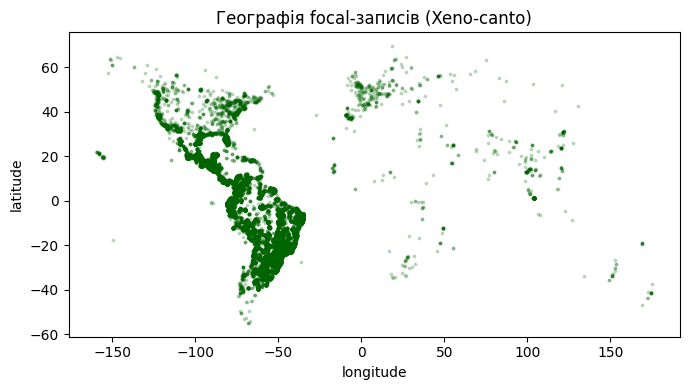

focal recordings with coords: 35549


In [16]:
lat = next((c for c in ["latitude", "lat"] if train is not None and c in train.columns), None)
lon = next((c for c in ["longitude", "lon", "lng"] if train is not None and c in train.columns), None)
if lat and lon:
    plt.figure(figsize=(7, 4))
    plt.scatter(train[lon], train[lat], s=3, alpha=0.2, color="darkgreen")
    plt.xlabel("longitude"); plt.ylabel("latitude")
    plt.title("Географія focal-записів (Xeno-canto)")
    savefig("09_geo.png")
    print("focal recordings with coords:", int(train[[lat, lon]].notna().all(1).sum()))
else:
    print("no lat/lon columns -> skip geo")